In [29]:
import torch
import torchvision
from torchvision import transforms as T
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cv2
from utils import load_nutrition_db, estimate_calories, estimate_mass, pixel_to_cm2, mask_area_pixels, find_marker_bbox_by_color


In [5]:
nutrition_db = load_nutrition_db("nutrition_db.json")
nutrition_db


{'cooked_rice': {'display_name': 'Cooked Rice',
  'kcal_per_100g': 130,
  'density_g_per_cm3': 1.3,
  'default_thickness_cm': 2.5},
 'grilled_chicken_breast': {'display_name': 'Grilled Chicken Breast',
  'kcal_per_100g': 165,
  'density_g_per_cm3': 1.05,
  'default_thickness_cm': 1.5},
 'salad_mixed_veg': {'display_name': 'Mixed Salad (raw)',
  'kcal_per_100g': 25,
  'density_g_per_cm3': 0.45,
  'default_thickness_cm': 1.0}}

In [10]:
class FoodDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = f"{self.img_dir}/{row['filename']}"
        img = Image.open(img_path).convert("RGB")
        label = row['class_name']
        if self.transform:
            img = self.transform(img)
        return img, label

transform = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
])

dataset = FoodDataset("labels.csv", "images", transform=transform)
loader = DataLoader(dataset, batch_size=4, shuffle=True)


In [36]:
import warnings
warnings.filterwarnings("ignore")
num_classes = len(dataset.data['class_name'].unique())
model = torchvision.models.mobilenet_v3_small(pretrained=True)
model.classifier[3] = torch.nn.Linear(model.classifier[3].in_features, num_classes)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)


In [43]:
# Example image
img_path = "img/rice.jpg"
predicted_class = "cooked_rice"  # Normally model prediction
portion_g = 150  # Estimated from mask / manual input

info = nutrition_db[predicted_class]
calories = estimate_calories(portion_g, info['kcal_per_100g'])
print(f"{predicted_class} estimated calories: {calories:.1f} kcal")


cooked_rice estimated calories: 195.0 kcal


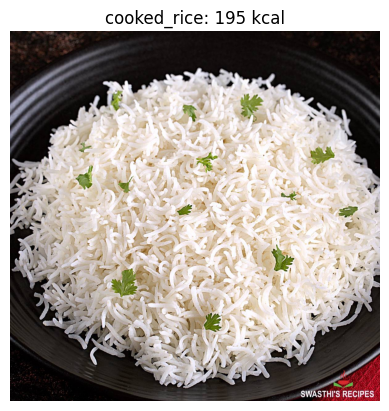

In [44]:
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR → RGB

plt.imshow(img)
plt.axis("off")
plt.title(f"{predicted_class}: {calories:.0f} kcal")
plt.show()
